In [64]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error as MSE

df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values

def prepare_data(sig, n, m):
    X, Y = [], []
    # O shift (s) é calculado para alinhar o final de Y com a predição futura
    # Seguindo sua lógica: se n=4, m=3 -> Y começa no índice 2 (hi_3)
    s = n - m + 1 
    
    for i in range(len(sig) - n - 1):
        X.append(sig[i : i + n])
        Y.append(sig[i + s : i + s + m])
        
    return np.array(X), np.array(Y)



In [ ]:
def generate_synthetic_series(n_points=500, slope=0.05, amplitude=10, period=50, noise_std=2):
    """
    Gera uma série temporal com tendência, sazonalidade e ruído.
    """
    time = np.arange(n_points)
    
    # 1. Tendência Linear
    trend = slope * time
    
    # 2. Sazonalidade (Onda senoidal)
    seasonality = amplitude * np.sin(2 * np.pi * time / period)
    
    # 3. Ruído Branco (Irregularidade)
    noise = np.random.normal(loc=0, scale=noise_std, size=n_points)
    
    # Série Final
    series = trend + seasonality + noise
    
    return time, series

# Gerando os dados
X, Y = generate_synthetic_series()

# Visualização
plt.figure(figsize=(12, 5))
plt.plot(X, Y, label='Série Temporal Sintética', color='blue', alpha=0.7)
plt.title('Dados de Série Temporal Gerados')
plt.xlabel('Tempo')
plt.ylabel('Valor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [2]:
xR = np.arange(6)[1:]
xP = xR + 0.1
m1 = MAPE(xR,xP)
df = 0
m2=0
k=1

for xr,xp in zip(xR,xP):
    df = np.abs((xr-xp)/xr)
    m2 = m2*(k-1)/k + df/k
    k=k+1


print(m1,m2)


0.04566666666666667 0.04566666666666666


In [130]:
class TimeSeriesNN_GD:
    def __init__(self, lr=0.01, epochs=900):
        self.lr, self.epochs = lr, epochs
        self.w, self.b = None, None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        #print(n_samples)
        self.w, self.b = np.zeros(n_features), 0
        losses = []
        for _ in range(self.epochs):
            #print(X)
            y_pred = np.dot(X, self.w) + self.b
            # Gradiente do MSE
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            losses.append(MSE(y, y_pred))
        return losses

    def predict(self, X):
        return np.dot(X, self.w) + self.b

class NNGD:
    def __init__(self, ni,lr=0.01):
        self.lr = lr
        self.w, self.b = np.zeros(ni), 0
        self.mse = 0
        self.losses = np.array([])
        self.δw = 0
        self.δb = 0
        self.k = 1
        self.yP = np.array([])
    def fit(self, X, yR):

        yP = np.dot(X, self.w) + self.b
        δw = np.dot(X.T, (yP - yR))
        δb = np.sum(yP - yR)
        mse = (yP-yR)**2
        self.δw = ((self.k-1)*self.δw + δw)/self.k 
        self.δb = ((self.k-1)*self.δb + δb)/self.k 
        self.w = self.w - self.lr*δw
        self.b = self.b - self.lr*δb
        self.mse = ((self.k-1)*self.mse + mse)/self.k 
        self.losses = np.append(self.losses,self.mse)
        self.k = self.k+1

    def predict(self, X):
        yP = np.dot(X, self.w) + self.b
        self.yP = np.append(self.yP,yP)

In [ ]:
class TimeSeriesNN_BFGS:
    def __init__(self, epochs=300):
        self.epochs = epochs
        self.params = None

    def get_grad(self, params, X, y):
        w, b = params[:-1], params[-1]
        y_pred = np.dot(X, w) + b
        dw = (1/len(y)) * np.dot(X.T, (y_pred - y))
        db = (1/len(y)) * np.sum(y_pred - y)
        return np.append(dw, db)

    def fit(self, X, y):
        n_features = X.shape[1]
        self.params = np.zeros(n_features + 1)
        I = np.eye(n_features + 1)
        H_inv = I
        losses = []
        
        for _ in range(self.epochs):
            g_old = self.get_grad(self.params, X, y)
            y_pred = np.dot(X, self.params[:-1]) + self.params[-1]
            losses.append(MSE(y, y_pred))
            p = -np.dot(H_inv, g_old)
            s = 0.1 * p # Passo simples
            
            g_new = self.get_grad(self.params, X, y)
            y_diff = g_new - g_old
            rho = 1.0 / (np.dot(y_diff, s) + 1e-10)

            # Atualização da Hessiana Aproximada (BFGS)
            A1 = I - rho * np.outer(s, y_diff)
            A2 = I - rho * np.outer(y_diff, s)
            H_inv = np.dot(A1, np.dot(H_inv, A2)) + (rho * np.outer(s, s))
        return losses

    def predict(self, X):
        return np.dot(X, self.params[:-1]) + self.params[-1]

class BFGS:
    def __init__(self,ni):
        self.k = 1
        self.ni = ni
        self.params = np.zeros(ni + 1)
        self.mse = 0
        self.H_inv = np.eye(self.ni  + 1)
        self.losses = np.array([])
        self.g = 0
        self.p = -np.dot(self.H_inv, g)


    def fit(self, X, yR):
        g_old = self.get_grad(self.params, X, yR)
        yP = np.dot(X, self.params[:-1]) + self.params[-1]
        mse = (yP-yR)**2
        self.mse = ((self.k-1)*self.mse + mse)/self.k 
        self.losses = np.append(self.losses,self.mse)


        self.k=self.k+1

    def predict(self, X):
        return np.dot(X, self.params[:-1]) + self.params[-1]


g_old [-0.08676815 -0.08698906 -0.08711327 -0.79742864]
g_new [-0.06070421 -0.0609112  -0.06104876 -0.71768578]
g_old [-0.06070421 -0.0609112  -0.06104876 -0.71768578]
g_new [-0.08293821 -0.08315697 -0.08328305 -0.63665037]
g_old [-0.08293821 -0.08315697 -0.08328305 -0.63665037]
g_new [-0.04451265 -0.04471083 -0.04485654 -0.56471385]
g_old [-0.04451265 -0.04471083 -0.04485654 -0.56471385]
g_new [-0.05326737 -0.05347009 -0.05361119 -0.50117162]
g_old [-0.05326737 -0.05347009 -0.05361119 -0.50117162]
g_new [-0.04271472 -0.04291168 -0.04305806 -0.45033601]
g_old [-0.04271472 -0.04291168 -0.04305806 -0.45033601]
g_new [-0.04029191 -0.04048742 -0.04063489 -0.40491465]
g_old [-0.04029191 -0.04048742 -0.04063489 -0.40491465]
g_new [-0.0355386  -0.0357314  -0.03588115 -0.36446089]
g_old [-0.0355386  -0.0357314  -0.03588115 -0.36446089]
g_new [-0.03223048 -0.03242132 -0.03257258 -0.32798383]
g_old [-0.03223048 -0.03242132 -0.03257258 -0.32798383]
g_new [-0.02889194 -0.02908078 -0.02923355 -0.29

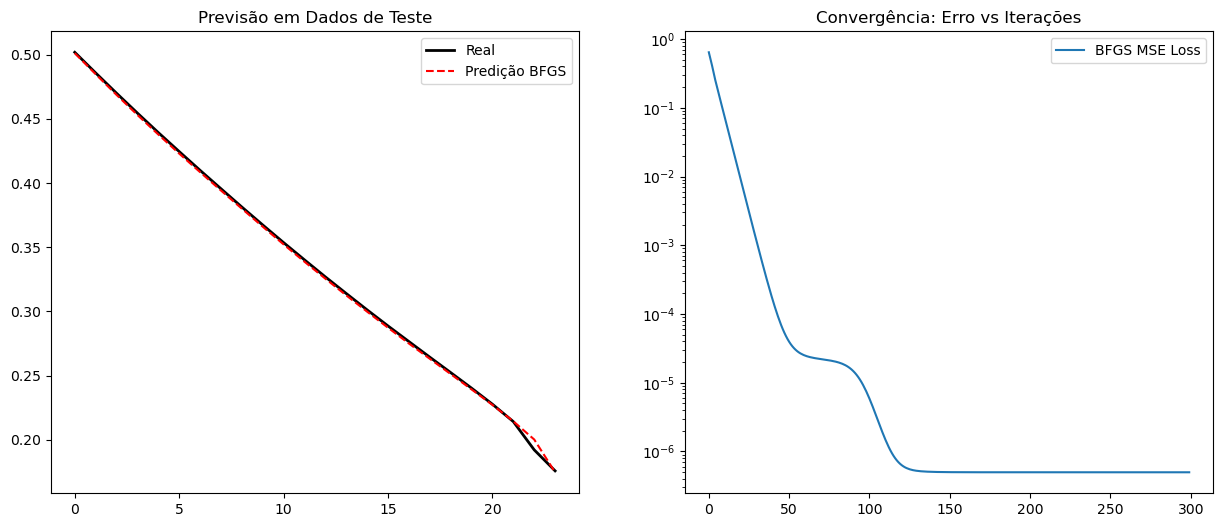

In [139]:
X, y = prepare_data(sig,3,1)
y = y.flatten()
# Divisão Treino/Teste (Séries temporais não devem ser embaralhadas aleatoriamente)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Normalização
scaler_x = StandardScaler()
X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)


bfgs_model = TimeSeriesNN_BFGS(epochs=300)
loss_bfgs = bfgs_model.fit(X_train, y_train)

# Previsões
pred_bfgs = bfgs_model.predict(X_test)

# Plotagem
plt.figure(figsize=(15, 6))

# Subplot 1: Comparação de Previsão
plt.subplot(1, 2, 1)
plt.plot(y_test, label='Real', color='black', lw=2)
plt.plot(pred_bfgs, label='Predição BFGS', color='red', linestyle='--')
plt.title('Previsão em Dados de Teste')
plt.legend()

# Subplot 2: Erro (Convergência)
plt.subplot(1, 2, 2)
plt.plot(loss_bfgs, label='BFGS MSE Loss')
plt.yscale('log') # Escala logarítmica para ver melhor a diferença
plt.title('Convergência: Erro vs Iterações')
plt.legend()

plt.show()



In [104]:
nS = 3
X2 = [X[i:i+nS] for i in range(len(X)-nS+1)]
Y2 = [Y[i:i+nS] for i in range(len(Y)-nS+1)]


[0.21406503 0.19205265 0.1757025 ]
[0.21406503 0.19205265 0.1757025 ]


In [131]:
ns = 5
ni = 3
X, Y = prepare_data(sig,ni,1)
Y = Y.flatten()
X2 = [X[i:i+ns] for i in range(len(X)-ns+1)]
Y2 = [Y[i:i+ns] for i in range(len(Y)-ns+1)]
nn = NNGD(ni=ni)

for X1,Y1 in zip(X2,Y2):
    for x,y in zip(X1,Y1):
        nn.fit(x,y)
    nn.predict(x)

yP = nn.yP
loss = nn.losses

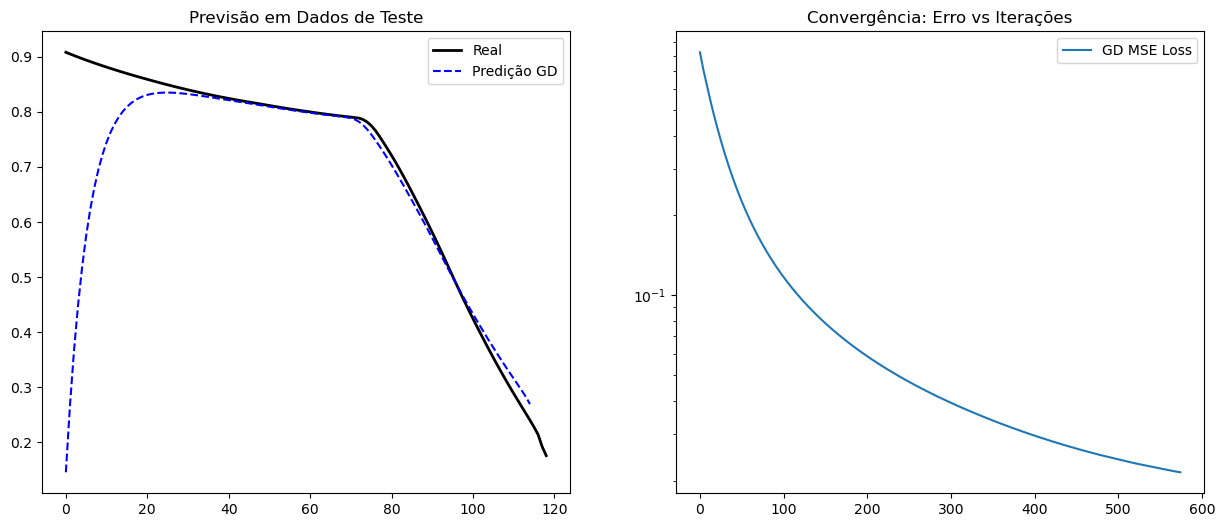

In [132]:
plt.figure(figsize=(15, 6))

# Subplot 1: Comparação de Previsão
plt.subplot(1, 2, 1)
plt.plot(Y, label='Real', color='black', lw=2)
plt.plot(yP, label='Predição GD', color='blue', linestyle='--')
plt.title('Previsão em Dados de Teste')
plt.legend()

# Subplot 2: Erro (Convergência)
plt.subplot(1, 2, 2)
plt.plot(loss, label='GD MSE Loss')
plt.yscale('log') # Escala logarítmica para ver melhor a diferença
plt.title('Convergência: Erro vs Iterações')
plt.legend()

plt.show()